In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Load config
with open('../models/config.json', 'r') as f:
    config = json.load(f)

device = torch.device(config['device'])

print("All imports successful!")
print(f"Device: {device}")

All imports successful!
Device: mps


In [2]:
IMG_SIZE   = config['img_size']
BATCH_SIZE = config['batch_size']
TEST_DIR   = config['test_dir']

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Rebuild ResNet50 architecture
def build_resnet50(num_classes=2):
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

# Load best saved weights
model = build_resnet50().to(device)
model.load_state_dict(torch.load('../models/best_resnet50.pth', map_location=device))
model.eval()

print("Best ResNet50 model loaded successfully!")
print(f"Test images: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Best ResNet50 model loaded successfully!
Test images: 624
Test batches: 20


In [3]:
all_preds   = []
all_labels  = []
all_probs   = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

correct  = (all_preds == all_labels).sum()
accuracy = 100 * correct / len(all_labels)

print(f"Test Accuracy : {accuracy:.2f}%")
print(f"Correct       : {correct}/{len(all_labels)}")
print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, 
                            target_names=['NORMAL', 'PNEUMONIA']))

Test Accuracy : 91.67%
Correct       : 572/624

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.95      0.82      0.88       234
   PNEUMONIA       0.90      0.97      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



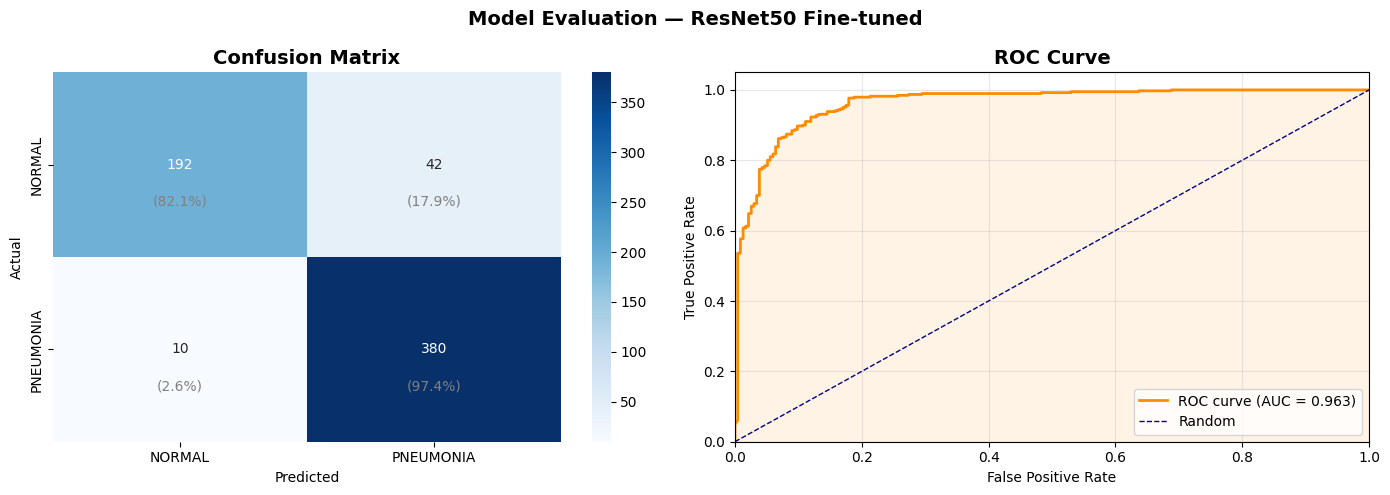

AUC-ROC Score: 0.9627


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Add percentages
for i in range(2):
    for j in range(2):
        total = cm[i].sum()
        pct   = 100 * cm[i][j] / total
        axes[0].text(j + 0.5, i + 0.7, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=10, color='gray')

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation — ResNet50 Fine-tuned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"AUC-ROC Score: {roc_auc:.4f}")

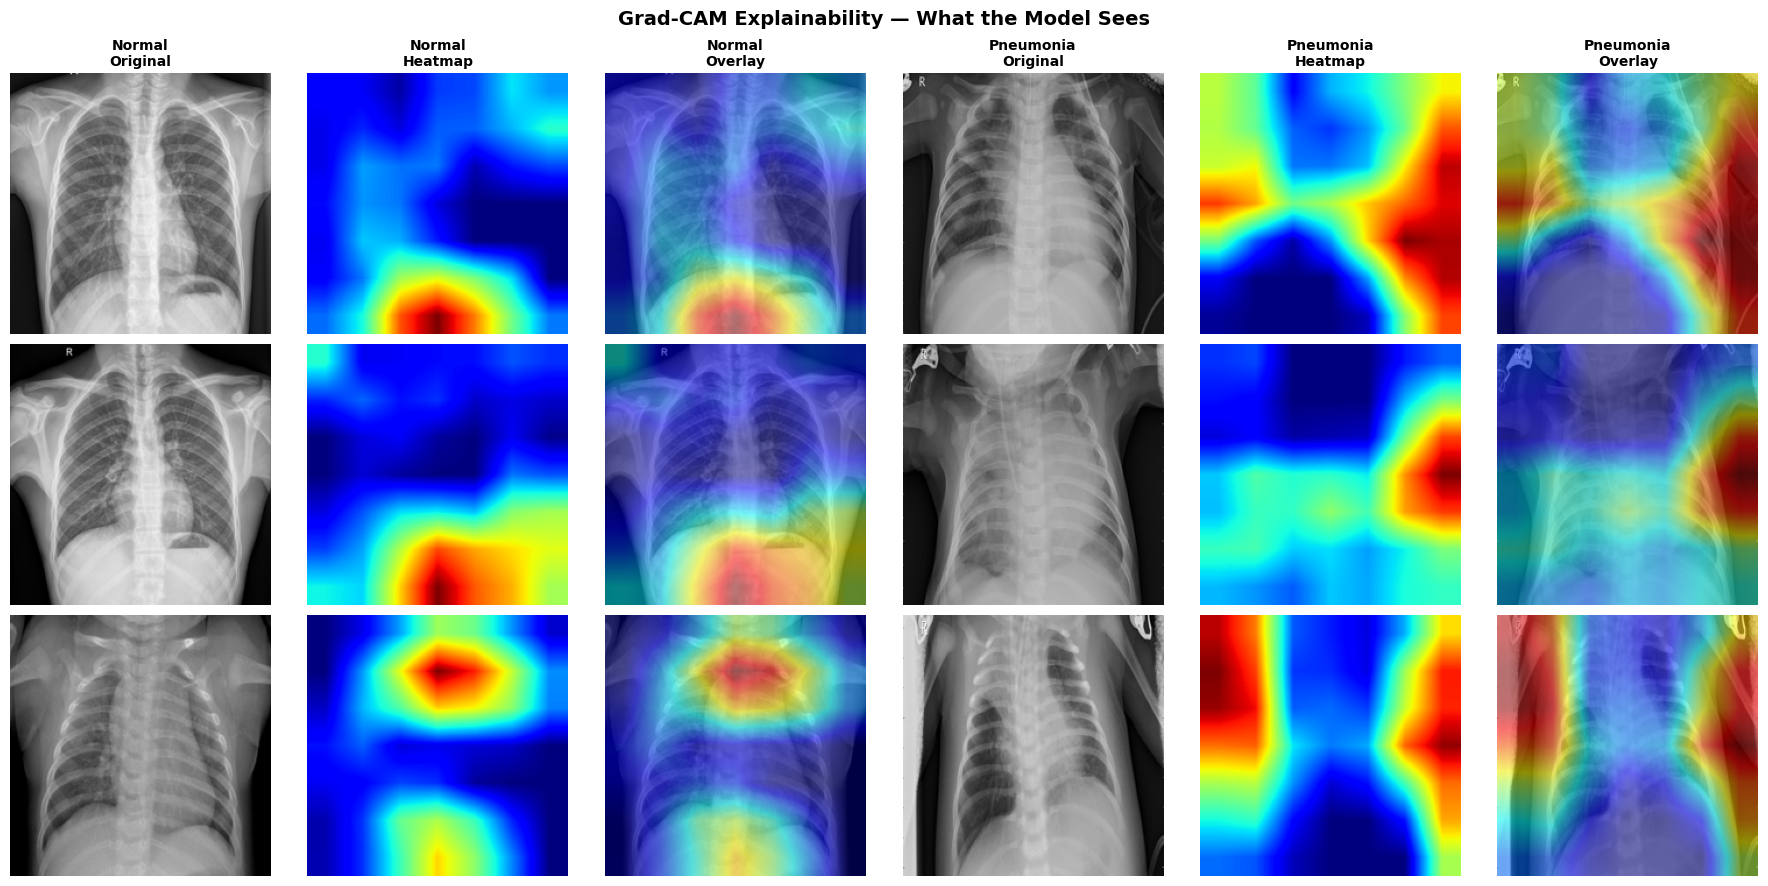

Grad-CAM visualization complete!


In [5]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Target the last conv layer of ResNet50
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Get sample images from test set
normal_dir    = os.path.join(TEST_DIR, 'NORMAL')
pneumonia_dir = os.path.join(TEST_DIR, 'PNEUMONIA')

def get_gradcam(img_path, label_name):
    # Load and preprocess
    img_pil = Image.open(img_path).convert('RGB')
    img_pil = img_pil.resize((224, 224))
    img_np  = np.array(img_pil) / 255.0

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Generate CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(img_np.astype(np.float32),
                                      grayscale_cam, use_rgb=True)
    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        prob   = torch.softmax(output, dim=1)
        pred   = output.argmax(1).item()
        confidence = prob[0][pred].item() * 100

    pred_name = 'PNEUMONIA' if pred == 1 else 'NORMAL'
    return img_np, grayscale_cam, visualization, pred_name, confidence

# Plot Grad-CAM for 3 normal + 3 pneumonia images
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
col_titles = ['Normal\nOriginal', 'Normal\nHeatmap', 'Normal\nOverlay',
              'Pneumonia\nOriginal', 'Pneumonia\nHeatmap', 'Pneumonia\nOverlay']

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=10, fontweight='bold')

normal_imgs    = [f for f in os.listdir(normal_dir)    if f.endswith('.jpeg')][:3]
pneumonia_imgs = [f for f in os.listdir(pneumonia_dir) if f.endswith('.jpeg')][:3]

for row in range(3):
    # Normal
    n_path = os.path.join(normal_dir, normal_imgs[row])
    orig, heatmap, overlay, pred, conf = get_gradcam(n_path, 'NORMAL')
    axes[row][0].imshow(orig)
    axes[row][0].axis('off')
    axes[row][1].imshow(heatmap, cmap='jet')
    axes[row][1].axis('off')
    axes[row][2].imshow(overlay)
    axes[row][2].set_xlabel(f'Pred: {pred} ({conf:.1f}%)', fontsize=8)
    axes[row][2].axis('off')

    # Pneumonia
    p_path = os.path.join(pneumonia_dir, pneumonia_imgs[row])
    orig, heatmap, overlay, pred, conf = get_gradcam(p_path, 'PNEUMONIA')
    axes[row][3].imshow(orig)
    axes[row][3].axis('off')
    axes[row][4].imshow(heatmap, cmap='jet')
    axes[row][4].axis('off')
    axes[row][5].imshow(overlay)
    axes[row][5].set_xlabel(f'Pred: {pred} ({conf:.1f}%)', fontsize=8)
    axes[row][5].axis('off')

plt.suptitle('Grad-CAM Explainability — What the Model Sees', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Grad-CAM visualization complete!")